<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA

### Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

In [1]:
!pip install --upgrade --no-cache-dir gdown --quiet

In [2]:
import re
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from keras.models import Model
from keras.layers import LSTM, Dense, Embedding, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer

In [3]:
# Descargar la carpeta de dataset
import os
import gdown
if os.access('data_volunteers.json', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    output = 'data_volunteers.json'
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [4]:
# dataset_file
import json

text_file = "data_volunteers.json"
with open(text_file) as f:
    data = json.load(f) # la variable data será un diccionario



In [5]:
# Observar los campos disponibles en cada linea del dataset
data[0].keys()

dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])

In [6]:
chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []
max_len = 30

def clean_text(txt):
    txt = txt.lower()
    txt.replace("\'d", " had")
    txt.replace("\'s", " is")
    txt.replace("\'m", " am")
    txt.replace("don't", "do not")
    txt = re.sub(r'\W+', ' ', txt)

    return txt

for line in data:
    for i in range(len(line['dialog'])-1):
        # vamos separando el texto en "preguntas" (chat_in)
        # y "respuestas" (chat_out)
        chat_in = clean_text(line['dialog'][i]['text'])
        chat_out = clean_text(line['dialog'][i+1]['text'])

        if len(chat_in) >= max_len or len(chat_out) >= max_len:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) tiene <eos>
        output_sentence = output + ' <eos>'
        # output sentence input (decoder_input) tiene <sos>
        output_sentence_input = '<sos> ' + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows utilizadas: 6033


In [7]:
input_sentences[1], output_sentences[1], output_sentences_inputs[1]

('hi how are you ', 'not bad and you  <eos>', '<sos> not bad and you ')

### ***Pueden realizar el desafio en Keras o PyTorch.***

### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

In [8]:
MAX_VOCAB_SIZE = 8000

# Tokenizer ENCODER
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_inputs))

max_input_len = max(len(s) for s in input_integer_seq)
print("Sentencia de entrada más larga:", max_input_len)

Palabras en el vocabulario: 1799
Sentencia de entrada más larga: 9


In [9]:
# Tokenizer DECODER
# filters sin <> para que <sos> y <eos> no se rompan
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE,
                             filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq       = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
print("Palabras en el vocabulario de salida:", len(word2idx_outputs))

max_out_len = max(len(s) for s in output_integer_seq)
print("Sentencia de salida más larga (tokens):", max_out_len)

Palabras en el vocabulario de salida: 1806
Sentencia de salida más larga (tokens): 10


In [10]:
# Limitar longitudes para no explotar la RAM
max_input_len = 10
max_out_len   = 10

print("Cantidad de rows del dataset:", len(input_integer_seq))

# Encoder: padding a la IZQUIERDA (pre), las últimas palabras quedan cerca del LSTM
# Decoder: padding a la DERECHA (post), la secuencia de salida empieza desde el índice 0
encoder_input_sequences = pad_sequences(input_integer_seq,
                                        maxlen=max_input_len)
decoder_input_sequences = pad_sequences(output_input_integer_seq,
                                        maxlen=max_out_len, padding='post')

print("encoder_input_sequences shape:", encoder_input_sequences.shape)
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

Cantidad de rows del dataset: 6033
encoder_input_sequences shape: (6033, 10)
decoder_input_sequences shape: (6033, 10)


In [11]:
from tensorflow.keras.utils import to_categorical

decoder_output_sequences = pad_sequences(output_integer_seq,
                                         maxlen=max_out_len, padding='post')

# one-hot para la loss categorical_crossentropy
decoder_targets = to_categorical(decoder_output_sequences,
                                 num_classes=num_words_output)

print("decoder_targets shape:", decoder_targets.shape)

decoder_targets shape: (6033, 10, 1807)


Se crean dos tokenizadores separados, uno para las preguntas (encoder) y otro para las respuestas (decoder).
El vocabulario se limita a 8000 palabras para controlar la memoria y por recomendación en la diapositiva.
El padding del encoder va a la izquierda para que el LSTM procese las palabras más importantes al final;
el del decoder va a la derecha porque la secuencia de salida se lee de corrido desde `<sos>`.

### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

In [12]:
import os

def is_valid_pickle(path):
    try:
        with open(path, "rb") as f:
            head = f.read(20)
        if b"<html" in head.lower() or b"<!doctype" in head.lower():
            return False
        return True
    except:
        return False

file_path = "fasttext.pkl"
file_id   = ""

if not os.path.exists(file_path) or not is_valid_pickle(file_path):
    if os.path.exists(file_path):
        os.remove(file_path)
    gdown.download(id=file_id, output=file_path, quiet=False)
    if not is_valid_pickle(file_path):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("Embeddings ya disponibles.")

Embeddings ya disponibles.


In [13]:
import logging, pickle
from pathlib import Path
import numpy as np

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug(
            'loading words embeddings from pickle {}'.format(
                self.PKL_PATH
            )
        )
        max_bytes = 2**28 - 1 # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug('words embeddings loaded')
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            'converting and loading words embeddings from text file {}'.format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1 # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        self.logger.debug('words embeddings loaded')
        return embeddings

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'cc.en.300.vec'
    PKL_PATH = 'fasttext.pkl'
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

model_embeddings = FasttextEmbeddings()
embed_dim = model_embeddings.N_FEATURES
print("Dimensión de embeddings:", embed_dim)

Dimensión de embeddings: 300


In [14]:
# Crear la Embedding matrix de las secuencias
# en inglés

print('preparing embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# word_index provieen del tokenizer

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs)) # vocab_size
embedding_matrix = np.zeros((nb_words, embed_dim))
for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:

        embedding_matrix[i] = embedding_vector
    else:
        # words not found in embedding index will be all-zeros.
        words_not_found.append(word)

print('number of null word embeddings:', np.sum(np.sum(embedding_matrix**2, axis=1) == 0))
print('number of words not found: %s / %s' % (len(words_not_found), nb_words))

preparing embedding matrix...
number of null word embeddings: 1
number of words not found: 0 / 1799


In [15]:
# # Matriz de embeddings para el ENCODER
# nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs))
# embedding_matrix = np.zeros((nb_words, embed_dim))
# words_not_found  = []

# for word, i in word2idx_inputs.items():
#     if i >= nb_words:
#         continue
#     vec = model_embeddings.get_words_embeddings([word])[0]
#     if vec is not None and len(vec) > 0:
#         embedding_matrix[i] = vec
#     else:
#         words_not_found.append(word)

# print("Embedding matrix shape:", embedding_matrix.shape)
# print("Palabras sin embedding:", len(words_not_found))

In [16]:
embedding_matrix.shape

(1799, 300)

Se usa el pickle de Fastext 300 provisto.
Se construye una matriz donde cada fila se llena con el vector semántico de FastText correspondiente al índice de la palabra dictado por el tokenizador. Aquellas palabras del vocabulario que no son encontradas en FastText quedan inicializadas con un vector de ceros.

### 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

In [17]:
n_units = 128

# ENCODER
encoder_inputs = Input(shape=(max_input_len,), name='encoder_input')

encoder_embedding_layer = Embedding(
    input_dim    = nb_words,
    output_dim   = embed_dim,
    #input_length = max_input_len, # deprecado
    weights      = [embedding_matrix],
    trainable    = False,
    name         = 'encoder_embedding'
)
encoder_inputs_x = encoder_embedding_layer(encoder_inputs)

encoder_outputs, state_h, state_c = LSTM(
    n_units, return_state=True, name='encoder_lstm'
)(encoder_inputs_x)
encoder_states = [state_h, state_c]

# DECODER
decoder_inputs = Input(shape=(max_out_len,), name='decoder_input')

decoder_embedding_layer = Embedding(
    input_dim    = num_words_output,
    output_dim   = n_units,
    #input_length = max_out_len, # deprecado
    name         = 'decoder_embedding'
)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True,
                    dropout=0.2, name='decoder_lstm')
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x,
                                     initial_state=encoder_states)

# DENSE
decoder_dense   = Dense(num_words_output, activation='softmax', name='decoder_dense')
decoder_outputs = decoder_dense(decoder_outputs)

# MODELO COMPLETO
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

2026-04-22 23:17:52.941807: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-22 23:17:52.941882: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-22 23:17:52.941885: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-04-22 23:17:52.941900: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-22 23:17:52.941909: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 10, 300)   │    539,700 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 10, 128)   │    231,296 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │    219,648 │ encoder_embeddin… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 10, 128), │    131,584 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 10, 1807)  │    233,103 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,355,331 (5.17 MB)

 Trainable params: 815,631 (3.11 MB)

 Non-trainable params: 539,700 (2.06 MB)

In [18]:
%pip install --upgrade --no-cache-dir pydot graphviz --quiet

Note: you may need to restart the kernel to use updated packages.


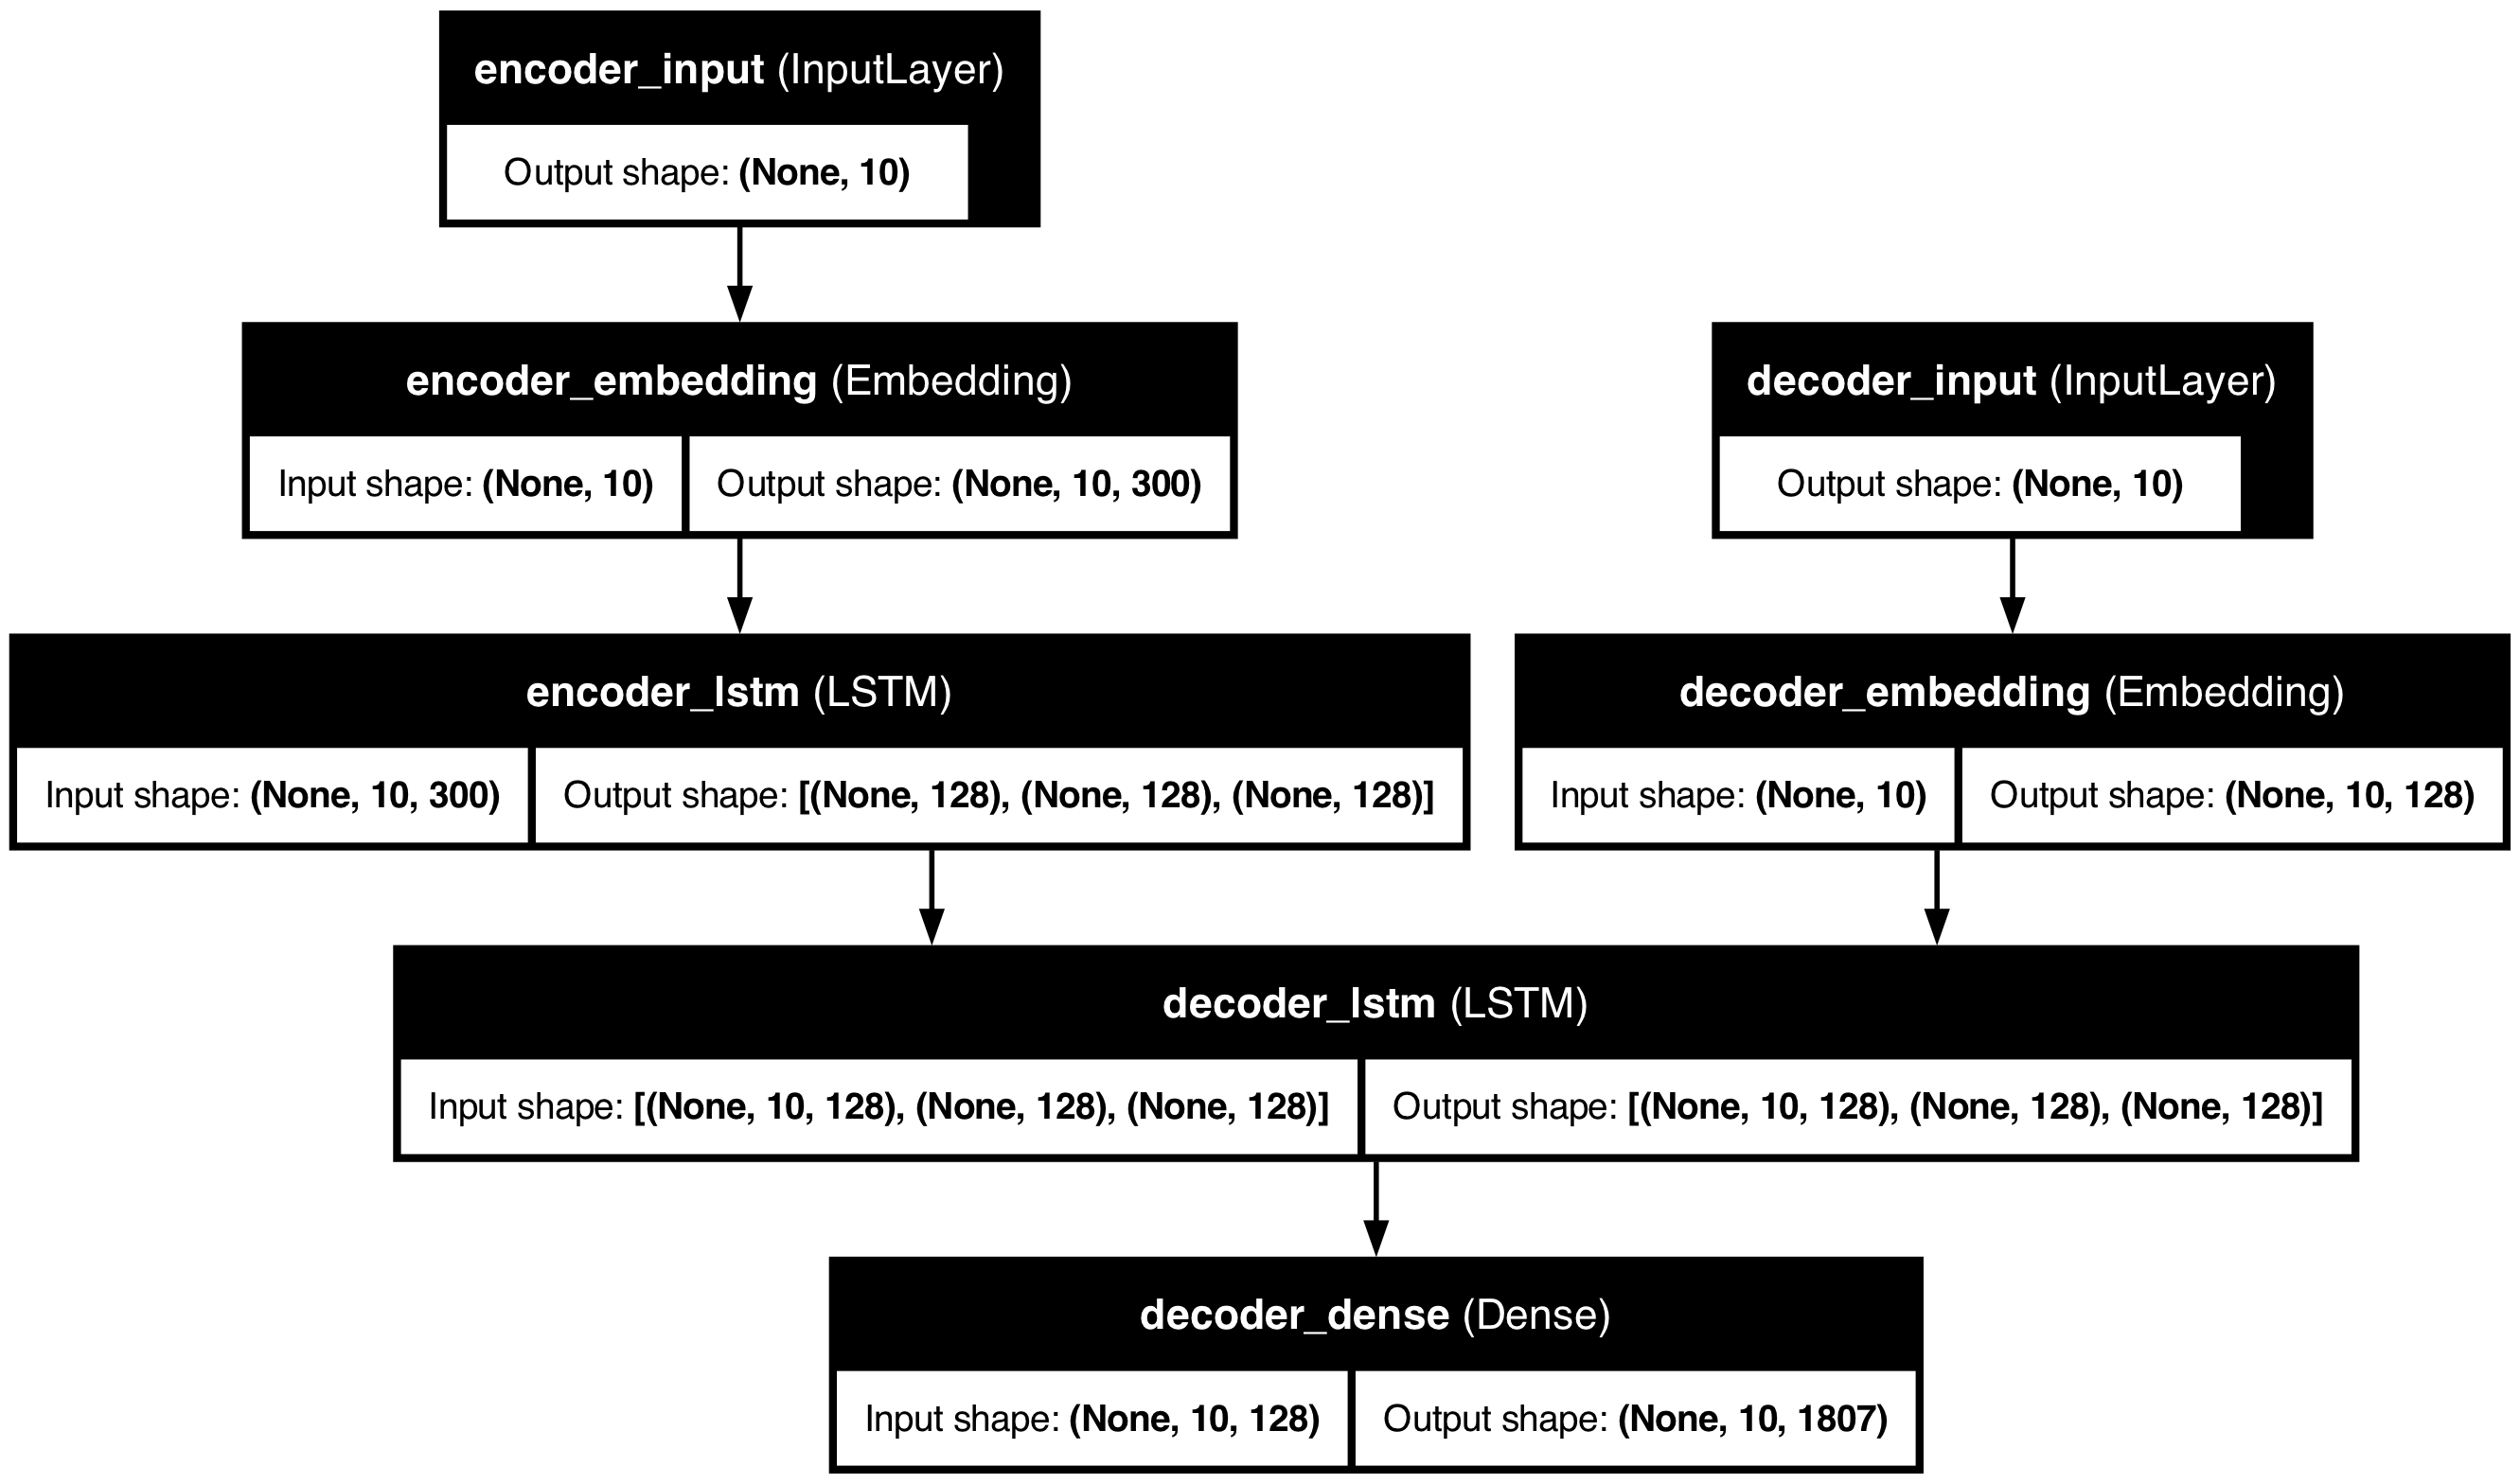

In [19]:
# Modelo completo (encoder+decoder) para poder entrenar
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Epoch 1/30


2026-04-22 23:17:56.004983: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5407 - loss: 3.4427 - val_accuracy: 0.6215 - val_loss: 2.2535
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6202 - loss: 2.0960 - val_accuracy: 0.6215 - val_loss: 2.1378
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6357 - loss: 1.9775 - val_accuracy: 0.6477 - val_loss: 2.0435
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6720 - loss: 1.8398 - val_accuracy: 0.6773 - val_loss: 1.9217
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6957 - loss: 1.7245 - val_accuracy: 0.6901 - val_loss: 1.8494
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7072 - loss: 1.6348 - val_accuracy: 0.7015 - val_loss: 1.7850
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7174 - loss: 1.5625 - val_accuracy: 0.7119 - val_loss: 1.7382
Epoch 8/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7263 - loss: 1.5025 - val_accuracy: 0.7113 - val_loss: 1.

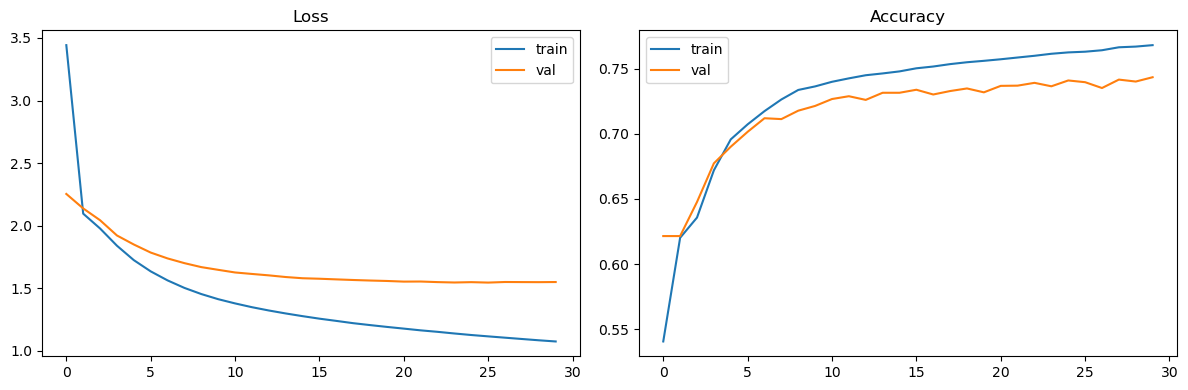

In [20]:
import matplotlib.pyplot as plt

hist = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    epochs          = 30,
    batch_size      = 64,
    validation_split= 0.1
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'],     label='train')
plt.plot(hist.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist.history['accuracy'],     label='train')
plt.plot(hist.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()

plt.tight_layout()
plt.show()

La arquitectura encoder-decoder del ejemplo del traductor: el encoder comprime la pregunta en dos vectores de estado (h, c) que inicializan el decoder. Se usa Dropout 0.2 en el decoder para regularizar. Los embeddings del encoder están fijos (FastText); los del decoder se aprenden desde cero para ajustarse a las respuestas del QA.

El Accuracy sigue creciendo en el tiempo pero con el risgo de sobreajuste teniendo en cuenta que el loss de validación queda asintótico.

### 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

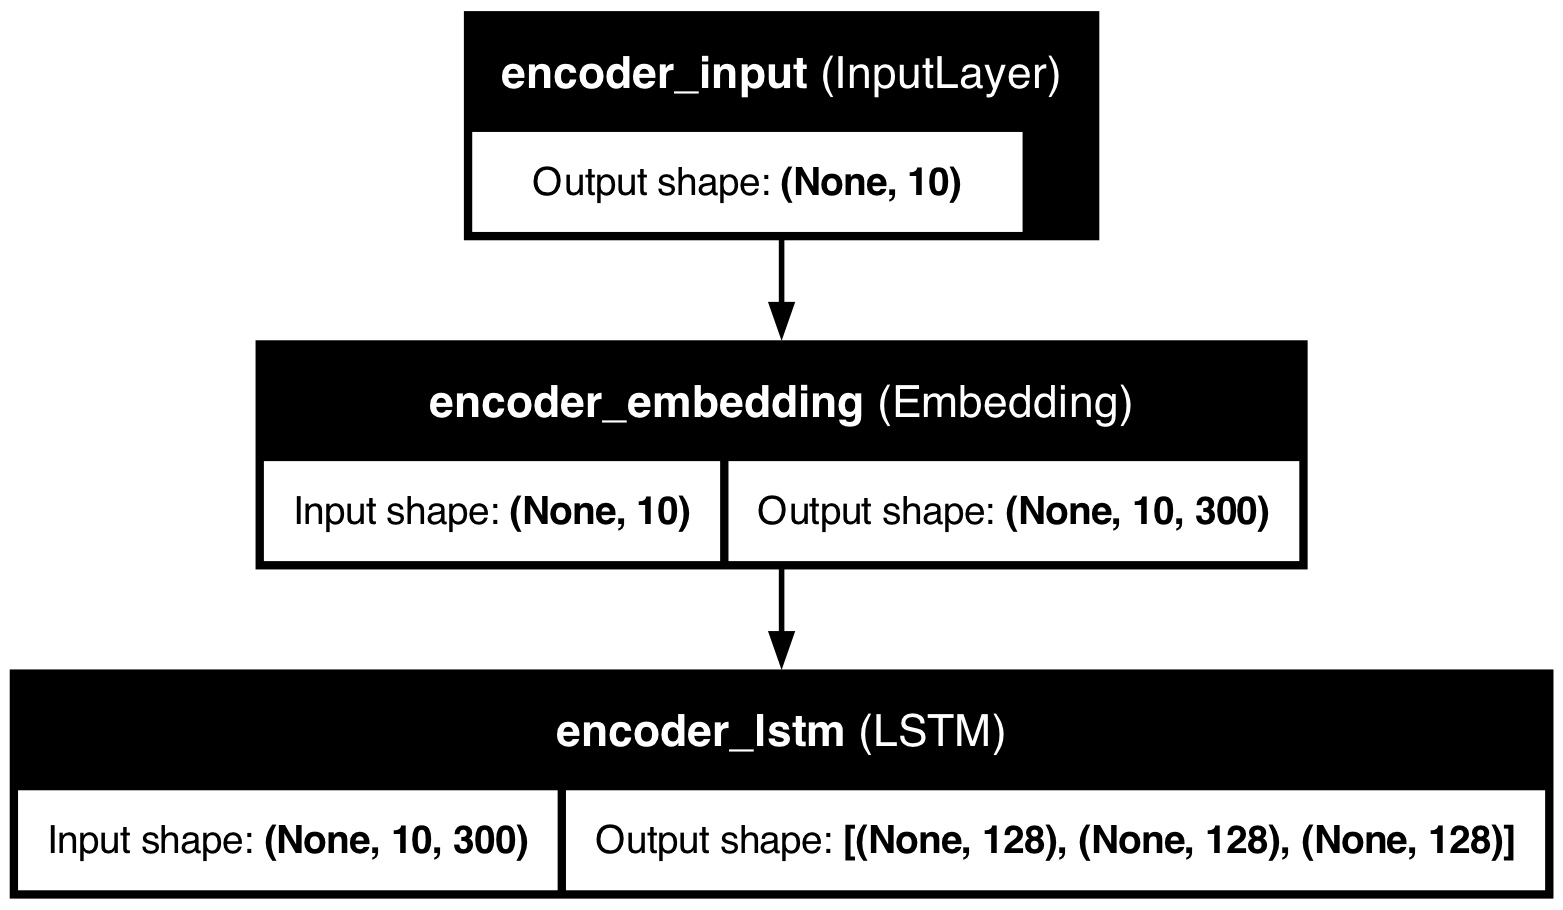

In [21]:
# ENCODER ────────────────────────────────────────────────
encoder_model = Model(encoder_inputs, encoder_states, name='encoder_inference')

plot_model(encoder_model, to_file='encoder_plot.png', show_shapes=True, show_layer_names=True)

Modelos de inferencia listos.


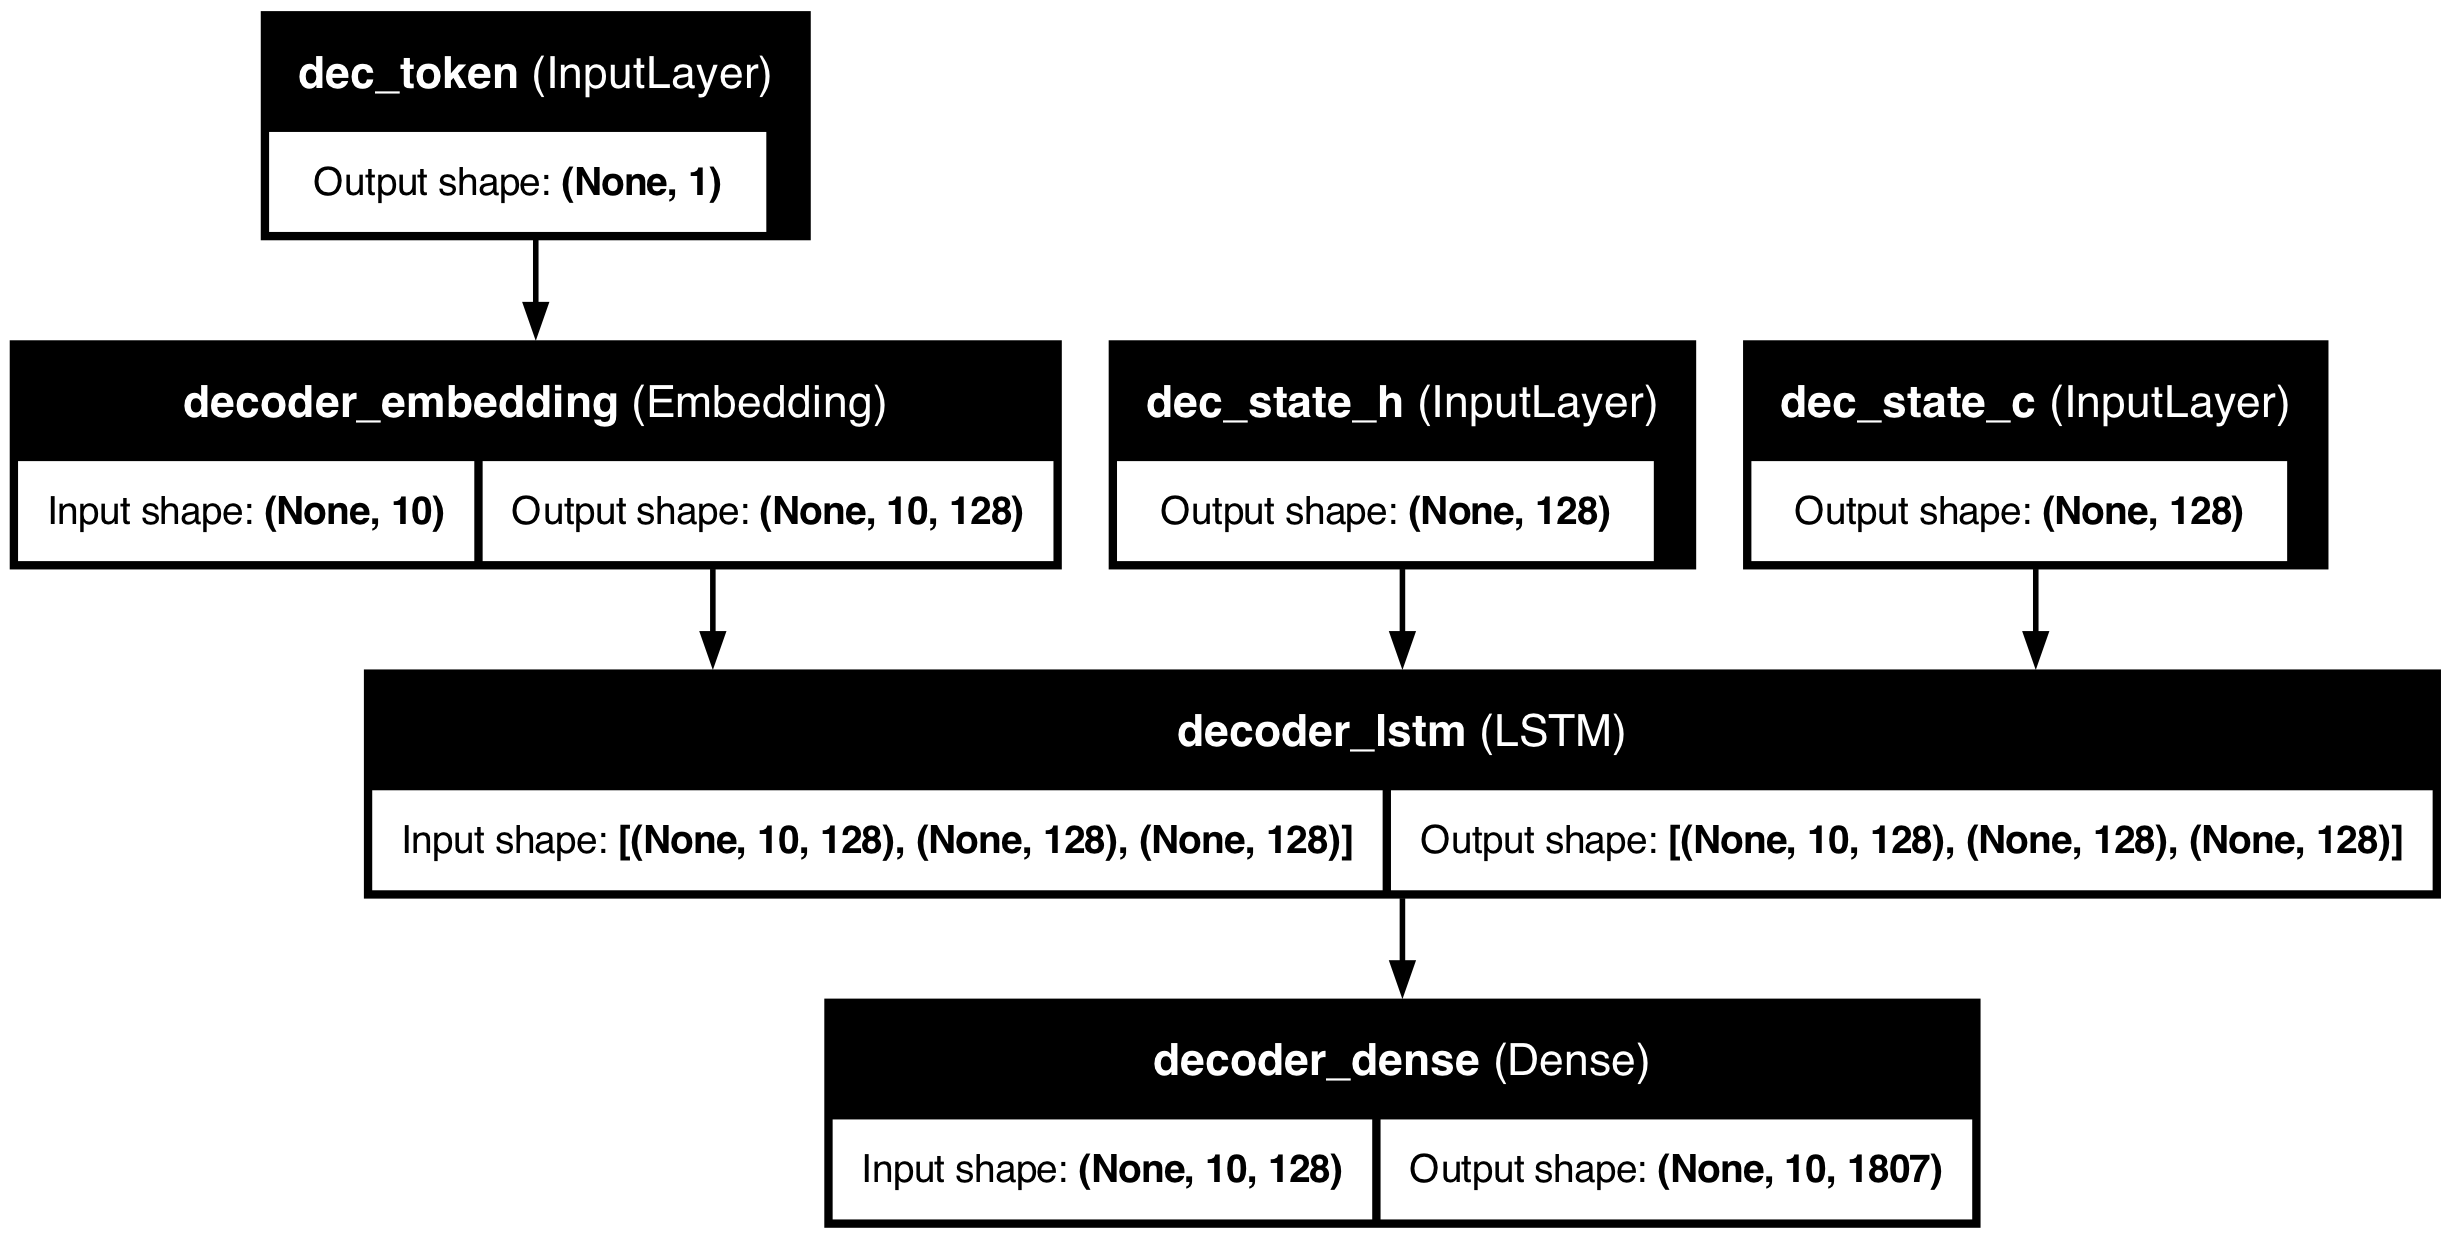

In [22]:
# Modelo inferencia DECODER
decoder_state_input_h = Input(shape=(n_units,), name='dec_state_h')
decoder_state_input_c = Input(shape=(n_units,), name='dec_state_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single   = Input(shape=(1,), name='dec_token')
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs_inf, h_inf, c_inf = decoder_lstm(
    decoder_inputs_single_x, initial_state=decoder_states_inputs
)
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [decoder_outputs_inf, h_inf, c_inf],
    name='decoder_inference'
)

print("Modelos de inferencia listos.")
plot_model(decoder_model, to_file='decoder_plot.png', show_shapes=True, show_layer_names=True)

In [23]:
idx2word_inputs  = {v: k for k, v in word2idx_inputs.items()}
idx2word_outputs = {v: k for k, v in word2idx_outputs.items()}


In [24]:
idx2word_outputs

{1: '<eos>',
 2: 'you',
 3: 'i',
 4: 'do',
 5: 'what',
 6: 'a',
 7: 'are',
 8: 'to',
 9: 'for',
 10: 'how',
 11: 'am',
 12: 'living',
 13: 'like',
 14: 'love',
 15: 'have',
 16: 'is',
 17: 'm',
 18: 'your',
 19: 'read',
 20: 'hello',
 21: 'oh',
 22: 'good',
 23: 'that',
 24: 'hi',
 25: 'it',
 26: 'the',
 27: 'any',
 28: 'not',
 29: 'yes',
 30: 'u',
 31: 'and',
 32: 'work',
 33: 'about',
 34: 'me',
 35: 's',
 36: 'in',
 37: 'no',
 38: 'my',
 39: 'ok',
 40: 'fine',
 41: 'from',
 42: 'today',
 43: 'of',
 44: 'hobbies',
 45: 'doing',
 46: 't',
 47: 'where',
 48: 'name',
 49: 'play',
 50: 'too',
 51: 'go',
 52: 'so',
 53: 'well',
 54: 'see',
 55: 'great',
 56: 'don',
 57: 'favorite',
 58: 'bye',
 59: 'pets',
 60: 'nice',
 61: 'know',
 62: 'there',
 63: 'at',
 64: 'hey',
 65: 'why',
 66: 'can',
 67: 'sure',
 68: 'live',
 69: 'cool',
 70: 'fun',
 71: 'thanks',
 72: 'old',
 73: 'games',
 74: 'beach',
 75: 'job',
 76: 'tell',
 77: 'with',
 78: 'student',
 79: 'mean',
 80: 'sorry',
 81: 'girl',


In [25]:

# v0
# def respond(input_seq):
#     """input_seq: array (1, max_input_len)."""
#     states_value = encoder_model.predict(input_seq, verbose=0)

#     target_seq = np.zeros((1, 1))
#     target_seq[0, 0] = word2idx_outputs['<sos>']
#     eos = word2idx_outputs['<eos>']

#     output_sentence = []
#     for _ in range(max_out_len):
#         output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
#         idx = np.argmax(output_tokens[0, 0, :])

#         # Primero chequeamos eos, ANTES de agregar nada
#         if idx == eos:
#             break

#         # Recién después agregamos la palabra
#         if idx > 0:
#             output_sentence.append(idx2word_outputs[idx])

#         states_value    = [h, c]
#         target_seq[0, 0] = idx

#     return ' '.join(output_sentence)

# v traductor
def respond(input_seq):
    # Se transforma la sequencia de entrada a los estados "h" y "c" de la LSTM
    # para enviar la primera vez al decoder
    states_value = encoder_model.predict(input_seq)

    # Se inicializa la secuencia de entrada al decoder como "<sos>"
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']

    # Se obtiene el índice que finaliza la inferencia
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        # Predicción del próximo elemento
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)
        idx = np.argmax(output_tokens[0, 0, :])

        # Si es "end of sentece <eos>" se acaba
        if eos == idx:
            break

        # Transformar idx a palabra
        word = ''
        if idx > 0:
            word = idx2word_outputs[idx]
            output_sentence.append(word)

        # Actualizar los estados dada la última predicción
        states_value = [h, c]

        # Actualizar secuencia de entrada con la salida (re-alimentación)
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

def chat(user_input):
    seq    = input_tokenizer.texts_to_sequences([user_input.lower()])
    padded = pad_sequences(seq, maxlen=max_input_len)   # padding izquierdo
    return respond(padded)

# v1
def sample_with_temperature(preds, temperature=0.7):
    # Transforma las probabilidades para dar espacio a respuestas más variadas
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-7) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

def respond_con_temperatura(input_seq, temp=0.7):
    states_value = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        
        # Usamos temperatura en vez de argmax
        preds = output_tokens[0, 0, :]
        idx = sample_with_temperature(preds, temperature=temp)

        if eos == idx:
            break

        if idx > 0:
            output_sentence.append(idx2word_outputs[idx])

        states_value = [h, c]
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

def chat_temp(user_input, temp=0.7):
    seq    = input_tokenizer.texts_to_sequences([user_input.lower()])
    padded = pad_sequences(seq, maxlen=max_input_len)
    return respond_con_temperatura(padded, temp)


In [26]:
# Probar con las preguntas sugeridas por la cátedra
test_questions = [
    "Do you read?",
    "Do you have any pet?",
    "Where are you from?",
    "Do you like radiohead?",
    "any drugs?",
    "marital status?",
]

for q in test_questions:
    print(f"You: {q}")
    print(f"Bottemperature: {chat_temp(q, 0.5)}")
    #print(f"Bot: {chat(q)}")
    print("-" * 50)

You: Do you read?
Bottemperature: i am a student
--------------------------------------------------
You: Do you have any pet?
Bottemperature: what do you do for a living
--------------------------------------------------
You: Where are you from?
Bottemperature: i am a vegan
--------------------------------------------------
You: Do you like radiohead?
Bottemperature: i am not sure i am a vegan
--------------------------------------------------
You: any drugs?
Bottemperature: what do you do for a living
--------------------------------------------------
You: marital status?
Bottemperature: i am not sure what you mean
--------------------------------------------------


Se construyen dos modelos separados reutilizando las capas entrenadas.
El encoder procesa la pregunta completa de una sola vez y entrega sus estados al decoder.
El decoder genera la respuesta token por token: arranca con `<sos>`, y cada palabra
predicha se realimenta como entrada del siguiente paso hasta llegar a `<eos>`.

Vemos resultados interesantes pero con limitaciones parecidas en el enfoque del traductor.

Algunos experimentos:

1. En una configuración base, se implementó el código del ejemplo  con los parámetros recomendados en la diapositiva para evitar la repetición del 'i am a vegan'. 

- `MAX_VOCAB_SIZE = 8000`
- `max_length = 10`  
- `Embeddings = 300`
- `n_units = 128`
- `LSTM Dropout = 0.2`
- `Epochs = 30~50`

 y aún así las respuestas repetitivas persisten con frecuencia de 'I love to read'

Con la inclusión de temperatura dinámica se obtuvieron resultados más dinámicos, y algunos de ellos interesantes semánticamente pero no la mayoría.

```
You: Do you read?
Bot: i like to read
--------------------------------------------------
You: Do you have any pet?
Bot: i am a vegan i am a vegan
--------------------------------------------------
You: Where are you from?
Bot: i am a teacher
--------------------------------------------------
You: Do you like radiohead?
Bot: i love to read
--------------------------------------------------
You: any drugs?
Bot: i am a student
--------------------------------------------------
You: marital status?
Bot: i m good thanks for asking
--------------------------------------------------
```

2. Secuencias más largas, más neuronas y aumento del vocabulario a 16000 no hacen una buena diferencia, ni en las curvas de entrenamiento ni en la calidad de las respuestas.

3. Apilamiento de dos capas LSTM en el encoder y decoder, mejoró levemente las métricas de entrenamiento, pero no logró un impacto significativo en la coherencia de las respuestas.

Conclusión:
En un trabajo siguiente se recomienda el uso de Transformers con mecanismos de atención (vistos en la clase 7). En lugar de procesar palabra por palabra y comprimirlas, la "Atención" permite que la red mire toda la oración al mismo tiempo y aprenda a darle importancia matemática solo a las palabras clave necesarias para generar una BUENA respuesta.


